# 作业3：概率论基础2

## 1
用矩阵分解的方式生成均值为$0$、方差符合以下方差-协方差矩阵的$1000$组的正态分布随机数；针对产生的随机数考察样本的方差-协方差特征。

矩阵为：
$$
\begin{bmatrix}
4 & 3 & 2 & 1 \\
3 & 4 & 3 & 2 \\
2 & 3 & 4 & 3 \\
1 & 2 & 3 & 4
\end{bmatrix}
$$


### (1)
用随机数字（如学号）初始化随机数生成器。

In [1]:
import numpy as np

np.random.seed(2021012579) # 学号

### (2)
生成$1000$组4元独立正态分布的随机变量样本。

In [2]:
n_samples = 1000 # 抽样重复次数
X = np.random.randn(n_samples, 4) # (1000, 4)

X.shape

(1000, 4)

### (3)
对方差-协方差矩阵进行分解。

In [3]:
cov_matrix = np.array([[4, 3, 2, 1],
                       [3, 4, 3, 2],
                       [2, 3, 4, 3],
                       [1, 2, 3, 4]])

M = np.linalg.cholesky(cov_matrix) # Cholesky分解

M @ M.T

array([[4., 3., 2., 1.],
       [3., 4., 3., 2.],
       [2., 3., 4., 3.],
       [1., 2., 3., 4.]])

### (4)
进一步形成具有相关特征的$1000$组4元正态分布随机变量样本。

In [4]:
Y = X @ M.T

Y.shape

(1000, 4)

### (5)
检视样本估计的方差协方差，以及与给定协方差矩阵的一致性。

In [5]:
sample_cov = np.cov(Y, rowvar=False)
print("样本协方差矩阵:\n", np.round(sample_cov, 3), end="\n\n")

cov_diff = sample_cov - cov_matrix
print("与给定协方差矩阵之差:\n", np.round(cov_diff, 3), end="\n\n")

print("误差:", np.round(np.linalg.norm(cov_diff, 'fro') / np.linalg.norm(cov_matrix, 'fro'), 4))

样本协方差矩阵:
 [[4.177 3.138 2.045 1.034]
 [3.138 4.088 3.031 1.97 ]
 [2.045 3.031 4.169 3.059]
 [1.034 1.97  3.059 3.941]]

与给定协方差矩阵之差:
 [[ 0.177  0.138  0.045  0.034]
 [ 0.138  0.088  0.031 -0.03 ]
 [ 0.045  0.031  0.169  0.059]
 [ 0.034 -0.03   0.059 -0.059]]

误差: 0.0305


## 2
根据海冰激光测高原理（下式），估计卫星反演得到的海冰厚度$H_i$的不确定性。

计算公式：
$$
H_i = F_s \frac{\rho_w}{\rho_w - \rho_i} + H_s \frac{\rho_s - \rho_w}{\rho_w - \rho_i}
$$

反演模型参数取值：
- $\rho_w = 1024 kg/m^3$
- $\rho_i = 920 kg/m^3$
- $\rho_s = 300 kg/m^3$
- MYI: $H_s = 0.3m$
- FYI: $H_s = 0.15m$

输入参数$F_s$和各反演模型参数的不确定性（以方差计）：
- $\sigma_{F_s} = 0.01m$
- $\sigma_{H_s} = 0.15m$
- $\sigma_{\rho_w} = 5 kg/m^3$
- $\sigma_{\rho_i} = 13 kg/m^3$
- $\sigma_{\rho_s} = 75 kg/m^3$

考察：$F_s=40cm$（MYI）和$F_s=15cm$（FYI）下冰厚$H_i$的不确定性及来源。

具体采用以下两种方式进行不确定性估计，并对估计结果进行比较。

### (1)
基于函数导数的误差传导估计。

误差传导：
$$
\sigma^2_{H_i} = (\frac{\partial H_i}{\partial F_s})^2 \sigma^2_{F_s}
+ (\frac{\partial H_i}{\partial H_s})^2 \sigma^2_{H_s}
+ (\frac{\partial H_i}{\partial \rho_w})^2 \sigma^2_{\rho_w}
+ (\frac{\partial H_i}{\partial \rho_s})^2 \sigma^2_{\rho_s}
+ (\frac{\partial H_i}{\partial \rho_i})^2 \sigma^2_{\rho_i}
$$

其中：
- $\frac{\partial H_i}{\partial F_s} = \frac{\rho_w}{\rho_w - \rho_i}$
- $\frac{\partial H_i}{\partial H_s} = \frac{\rho_s}{\rho_w - \rho_i}$
- $\frac{\partial H_i}{\partial \rho_w} = -\frac{F_s \rho_i + H_s \rho_s}{(\rho_w - \rho_i)^2}$
- $\frac{\partial H_i}{\partial \rho_s} = \frac{H_s}{\rho_w - \rho_i}$
- $\frac{\partial H_i}{\partial \rho_i} = \frac{F_s \rho_w + H_s \rho_s}{(\rho_w - \rho_i)^2}$

### (2)
基于蒙特卡洛模拟（Monte-Carlo Simulation）随机试验进行估计

In [6]:
import numpy as np

np.random.seed(2021012579) # 学号

# 参数
rho_w = 1024.0      # kg/m³
rho_i = 920.0       # kg/m³
rho_s = 300.0       # kg/m³

sigma_Fs = 0.01     # m
sigma_Hs = 0.15     # m
sigma_rho_w = 5.0   # kg/m³
sigma_rho_i = 13.0  # kg/m³
sigma_rho_s = 75.0  # kg/m³


def calculate_uncertainty(case:dict):
    """Calculate the uncertainty of ice thickness based on the given case."""
    Fs = case['Fs']
    Hs = case['Hs']

    denominator = rho_w - rho_i
    denom_sq = denominator ** 2
    Hi = (Fs * rho_w + Hs * (rho_s - rho_w)) / denominator

    dHi_dFs = rho_w / denominator
    dHi_dHs = rho_s / denominator
    dHi_drho_w = -(Fs * rho_i + Hs * rho_s) / denom_sq
    dHi_drho_s = Hs / denominator
    dHi_drho_i = (Fs * rho_w + Hs * rho_s) / denom_sq

    var_Fs = (dHi_dFs ** 2) * (sigma_Fs ** 2)
    var_Hs = (dHi_dHs ** 2) * (sigma_Hs ** 2)
    var_rho_w = (dHi_drho_w ** 2) * (sigma_rho_w ** 2)
    var_rho_s = (dHi_drho_s ** 2) * (sigma_rho_s ** 2)
    var_rho_i = (dHi_drho_i ** 2) * (sigma_rho_i ** 2)

    sigma_Hi = np.sqrt(var_Fs + var_Hs + var_rho_w + var_rho_s + var_rho_i)
    contributions = [var_Fs, var_Hs, var_rho_w, var_rho_s, var_rho_i]
    percentages = [c / sum(contributions) * 100 for c in contributions]

    return Hi, sigma_Hi, contributions, percentages


def monte_carlo_simulation(case, n_samples=1000000):
    """Use Monte Carlo simulation to estimate the uncertainty of ice thickness."""
    Fs = case['Fs']
    Hs = case['Hs']

    denominator = rho_w - rho_i
    Hi = (Fs * rho_w + Hs * (rho_s - rho_w)) / denominator

    contributions = np.zeros(5)
    param_simulations = [
        (np.random.normal(Fs, sigma_Fs, n_samples), Hs, rho_w, rho_s, rho_i),
        (Fs, np.random.normal(Hs, sigma_Hs, n_samples), rho_w, rho_s, rho_i),
        (Fs, Hs, np.random.normal(rho_w, sigma_rho_w, n_samples), rho_s, rho_i),
        (Fs, Hs, rho_w, np.random.normal(rho_s, sigma_rho_s, n_samples), rho_i),
        (Fs, Hs, rho_w, rho_s, np.random.normal(rho_i, sigma_rho_i, n_samples))]

    for i, (Fs_s, Hs_s, rw_s, rs_s, ri_s) in enumerate(param_simulations):
        denominator_s = rw_s - ri_s
        Hi_s = (Fs_s * rw_s + Hs_s * (rs_s - rw_s)) / denominator_s
        contributions[i] = np.var(Hi_s)

    total_var = np.sum(contributions)
    sigma_Hi = np.sqrt(total_var)
    percentages = (contributions / total_var) * 100

    return Hi, sigma_Hi, contributions.tolist(), percentages.tolist()


cases = [
    {'name': 'MYI (Fs=40cm)', 'Fs': 0.4, 'Hs': 0.3},
    {'name': 'FYI (Fs=15cm)', 'Fs': 0.15, 'Hs': 0.15}
]

=== MYI (Fs=40cm) ===
[Error Propagation 计算结果]
Hi = 1.8500 m
σ_Hi = 0.8057 m
各误差源贡献比例:
= Fs: 1.49%
= Hs: 28.84%
= rho_w: 6.91%
= rho_s: 7.21%
= rho_i: 55.55%
[Monte Carlo Simulation 计算结果]
Hi = 1.8500 m
σ_Hi = 1.1025 m
各误差源贡献比例:
= Fs: 0.80%
= Hs: 89.71%
= rho_w: 0.59%
= rho_s: 3.86%
= rho_i: 5.04%


=== FYI (Fs=15cm) ===
[Error Propagation 计算结果]
Hi = 0.4327 m
σ_Hi = 0.5223 m
各误差源贡献比例:
= Fs: 3.55%
= Hs: 68.64%
= rho_w: 2.62%
= rho_s: 4.29%
= rho_i: 20.89%
[Monte Carlo Simulation 计算结果]
Hi = 0.4327 m
σ_Hi = 1.0557 m
各误差源贡献比例:
= Fs: 0.87%
= Hs: 97.74%
= rho_w: 0.04%
= rho_s: 1.05%
= rho_i: 0.30%




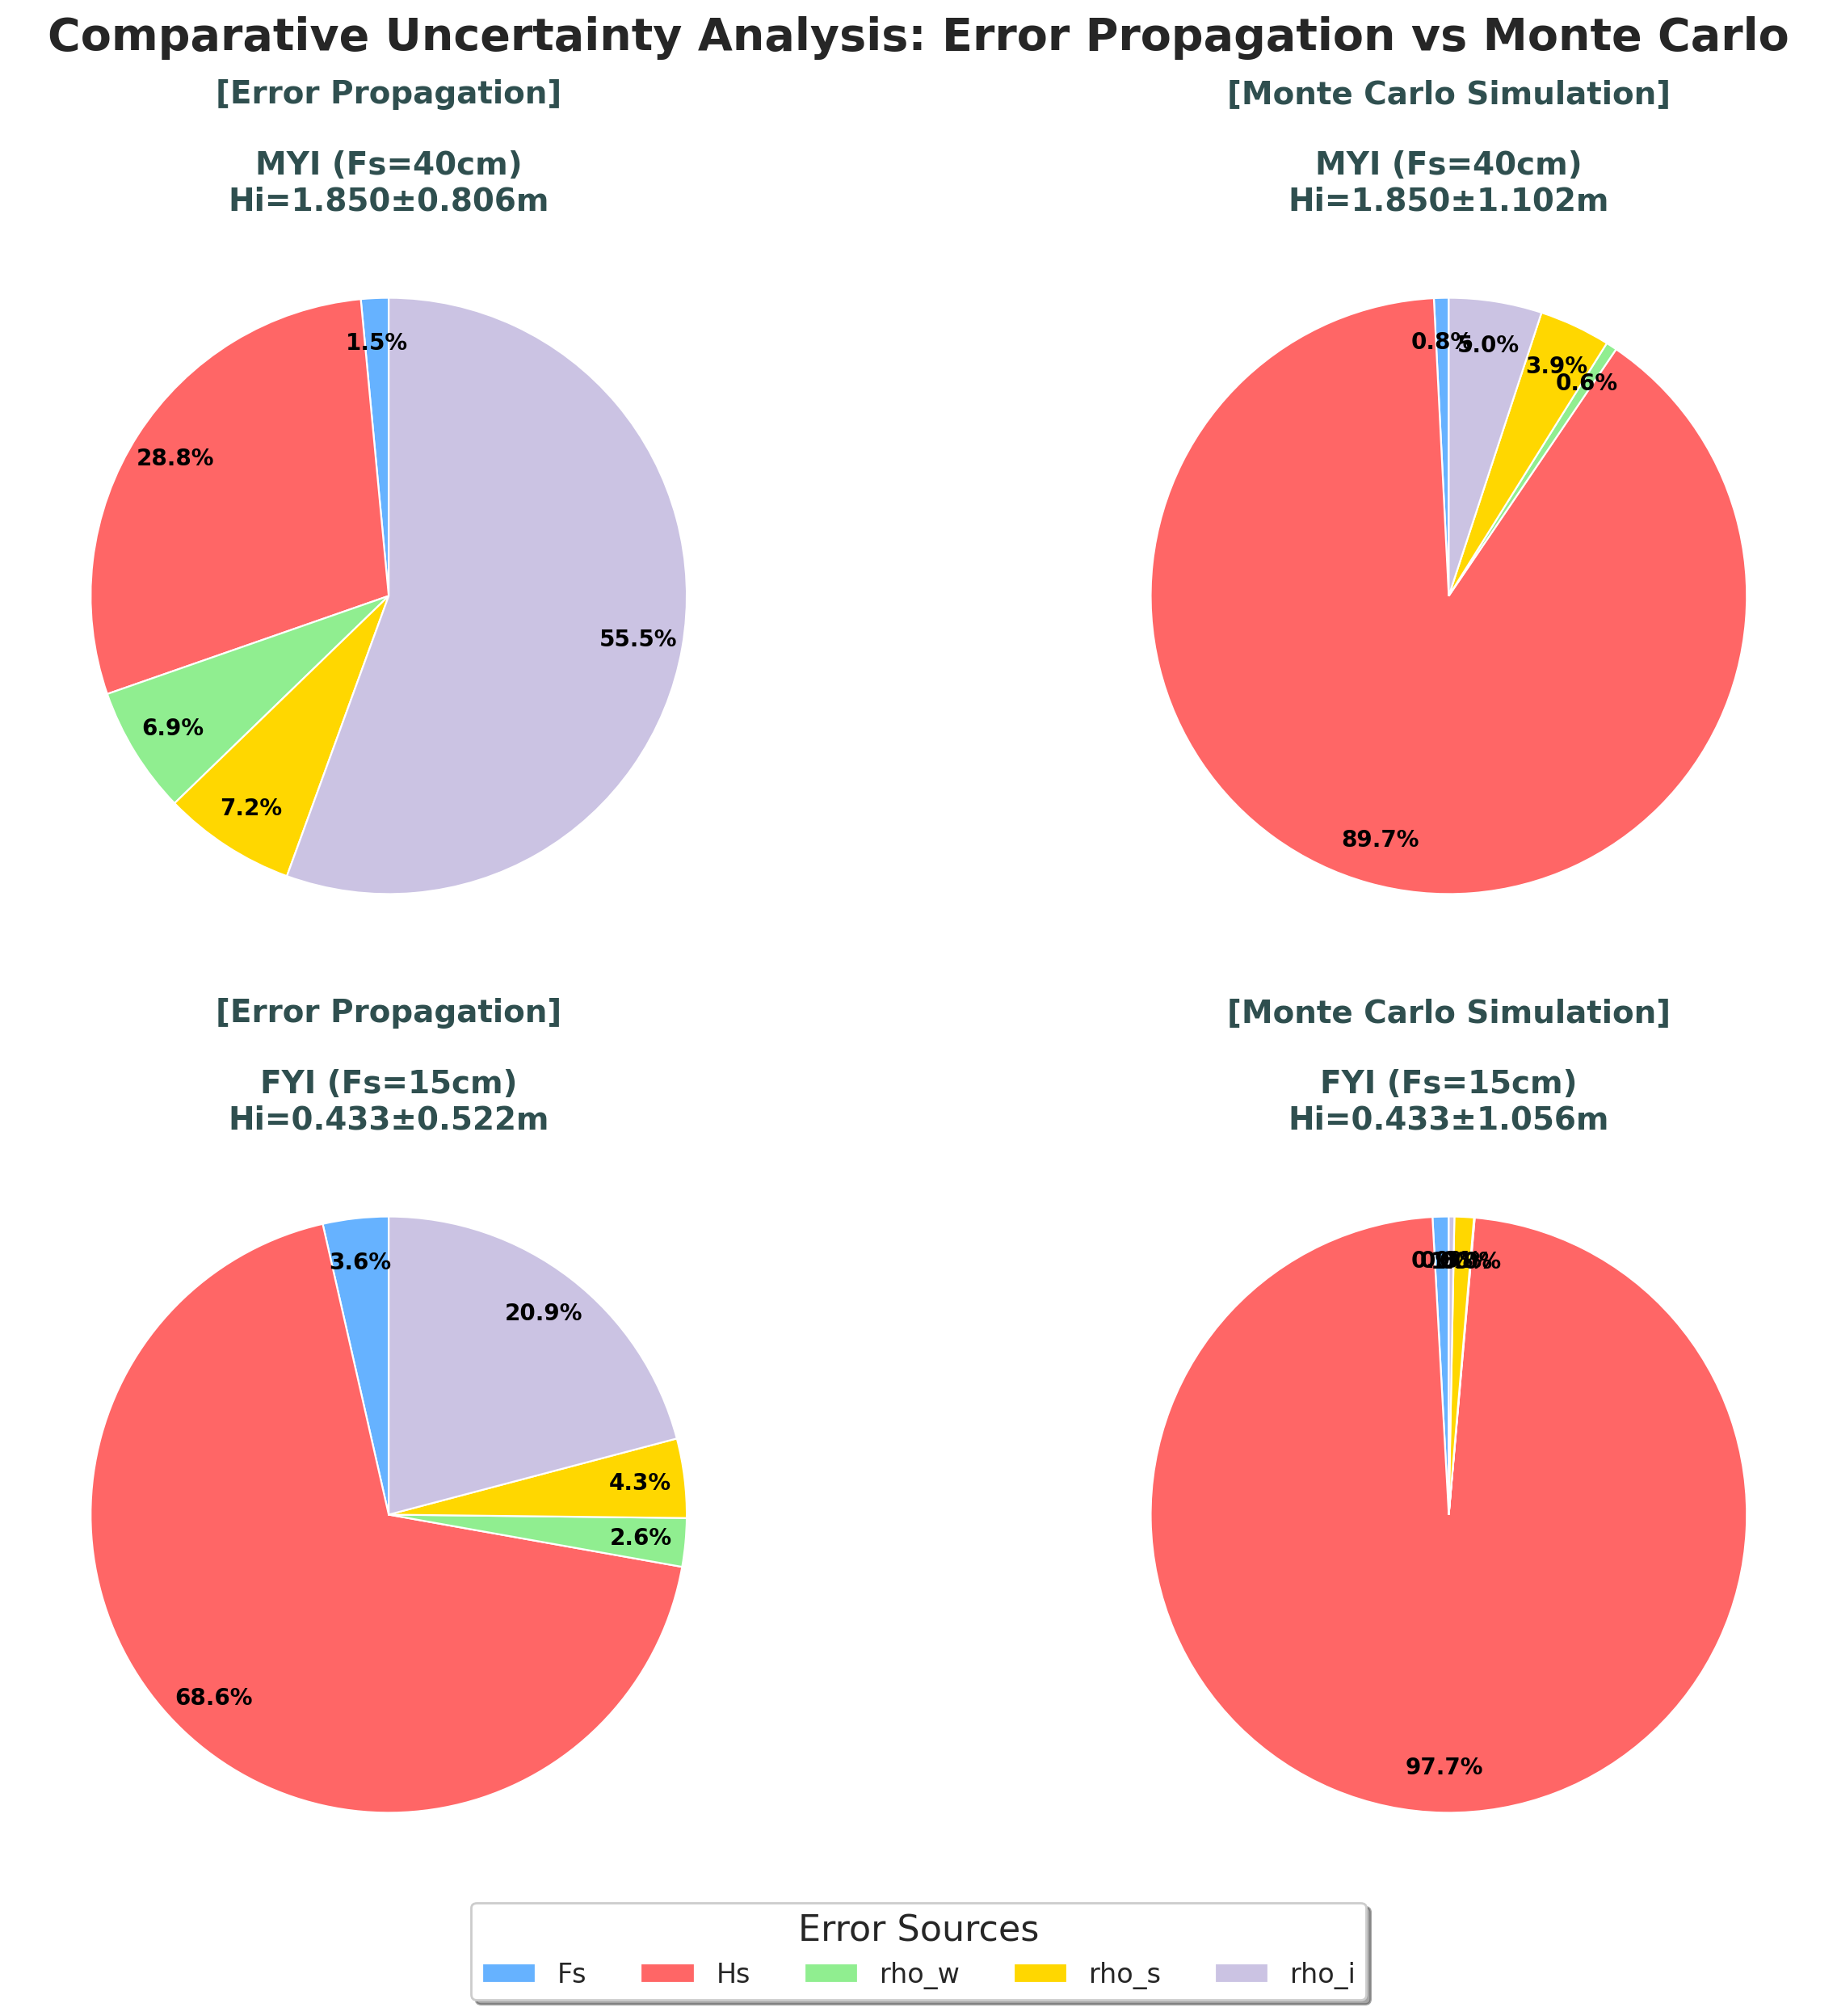

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel",
                rc={'axes.titlesize': 14,
                    'axes.labelsize': 12,
                    'legend.frameon': True,
                    'legend.shadow': True,
                    'legend.framealpha': 0.9})

sources = ['Fs', 'Hs', 'rho_w', 'rho_s', 'rho_i']
palette = ["#66B2FF", "#FF6666", "#90EE90", "#FFD700", "#CBC3E3"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=200)
fig.suptitle("Comparative Uncertainty Analysis: Error Propagation vs Monte Carlo", fontsize=20, weight='bold')

method_names = ['Error Propagation', 'Monte Carlo Simulation']
case_positions = {'MYI (Fs=40cm)': 0, 'FYI (Fs=15cm)': 1}

plot_config = {
    'title_size': 14,
    'result_font': {'size': 14, 'color': '#2F4F4F', 'weight': 'semibold'},
    'legend_pos': (-0.25, 0.8),
    'wedge_style': {'linewidth': 0.8, 'edgecolor': 'white'},
    'pct_style': {'color': 'black', 'fontsize': 10, 'weight': 'semibold'}
}
for case_idx, case in enumerate(cases):
    Hi_ep, sigma_ep, _, perc_ep = calculate_uncertainty(case)
    Hi_mc, sigma_mc, _, perc_mc = monte_carlo_simulation(case)

    print(f"=== {case['name']} ===")
    print(f"[{method_names[0]} 计算结果]")
    print(f"Hi = {Hi_ep:.4f} m")
    print(f"σ_Hi = {sigma_ep:.4f} m")
    print("各误差源贡献比例:")
    for src, percent in zip(sources, perc_ep):
        print(f"= {src}: {percent:.2f}%")
    print(f"[{method_names[1]} 计算结果]")
    print(f"Hi = {Hi_mc:.4f} m")
    print(f"σ_Hi = {sigma_mc:.4f} m")
    print("各误差源贡献比例:")
    for src, percent in zip(sources, perc_mc):
        print(f"= {src}: {percent:.2f}%")
    print("\n")

    titles = [
        f"[{method_names[0]}]\n\n{case['name']}\nHi={Hi_ep:.3f}±{sigma_ep:.3f}m",
        f"[{method_names[1]}]\n\n{case['name']}\nHi={Hi_mc:.3f}±{sigma_mc:.3f}m"]

    wedges = []
    for method_idx in range(2):
        ax = axes[case_idx, method_idx]
        data = perc_ep if method_idx == 0 else perc_mc
        w, _, t = ax.pie(
            data,
            colors=palette,
            startangle=90,
            wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'},
            textprops={'fontsize': 10},
            autopct='%1.1f%%',
            pctdistance=0.85
        )
        wedges.extend(w)
        ax.set_title(titles[method_idx], fontsize=14, color='#2F4F4F', weight='semibold')
        for autotext in t:
            autotext.set_color('black')
            autotext.set_fontsize(10)
            autotext.set_weight('semibold')


fig.legend(wedges[:5], sources,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.05),
            ncol=5,
            fontsize=12,
            title="Error Sources",
            title_fontsize=16,
            frameon=True,
            shadow=True)

plt.subplots_adjust(wspace=0.15, hspace=0.25, left=0.05, right=0.95, bottom=0.15, top=0.9)
plt.tight_layout()
plt.show()

## 3
基于Hadley SST数据1900~2010年数据，考察以下两个赤道太平洋与两个南北太平洋位置SST及其矩平（anomaly）的相关性特征。

### (1)
位置信息：
- 赤道太平洋 (160.5W, 0.5N)
- 赤道太平洋 (100.5W, 0.5N)
- 北太平洋 (160.5W,30.5N)
- 南太平洋(160.5W, 30.5S)

### (2)
计算原始SST序列的相关性（Pearson’s Correlation Coefficient）以及相关的显著性。

### (3)
计算SST矩平序列的相关性、以及显著性。

### (4)
矩平计算需注意：需要在SST时间序列上扣除当地的季节循环和长期变化趋势，可考虑去除平均季节循环或长度为整年的滑动平均。

In [ ]:
import xarray as xr
from scipy.stats import pearsonr
from itertools import combinations
FILE_PATH = "/home/binrui/repository/Courses/大数据/HadISST.nc"

sst = xr.open_dataset(FILE_PATH)['sst']
clim = sst.groupby('time.month').mean('time') # 月平均气候态
ssta = sst.groupby('time.month') - clim # 去季节循环
ssta_sm = ssta.rolling(time=12, center=True).mean('time') # 12个月滑动平均
ssta = ssta - ssta_sm # 去长期趋势

sst = sst.sel(time=slice('1900-01', '2010-12'))
ssta = ssta.sel(time=slice('1900-01', '2010-12'))

points = {
    'Eq_Pac_W': {'lon': -160.5, 'lat': 0.5}, # 赤道太平洋西部
    'Eq_Pac_E': {'lon': -100.5, 'lat': 0.5}, # 赤道太平洋东部
    'N_Pac': {'lon': -160.5, 'lat': 30.5},   # 北太平洋
    'S_Pac': {'lon': -160.5, 'lat': -30.5}   # 南太平洋
}

sst_series = {}
ssta_series = {}
for name, coords in points.items():
    sst_series[name] = sst.sel(lon=coords['lon'], lat=coords['lat'], method='nearest')
    ssta_series[name] = ssta.sel(lon=coords['lon'], lat=coords['lat'], method='nearest')

print("[原始SST相关性分析结果]")
for (a, b) in combinations(sst_series.keys(), 2):
    corr, p_val = pearsonr(sst_series[a].values, sst_series[b].values)
    print(f"{a} 与 {b} 的相关系数: {corr:.3f}, p值: {p_val:.4f}")
print()

print("[SST异常相关性分析结果]")
for (a, b) in combinations(ssta_series.keys(), 2):
    corr, p_val = pearsonr(ssta_series[a].values, ssta_series[b].values)
    print(f"{a} 与 {b} 的相关系数: {corr:.3f}, p值: {p_val:.4f}")
print()

[原始SST相关性分析结果]
Eq_Pac_W 与 Eq_Pac_E 的相关系数: 0.311, p值: 0.0000
Eq_Pac_W 与 N_Pac 的相关系数: 0.116, p值: 0.0000
Eq_Pac_W 与 S_Pac 的相关系数: -0.295, p值: 0.0000
Eq_Pac_E 与 N_Pac 的相关系数: -0.718, p值: 0.0000
Eq_Pac_E 与 S_Pac 的相关系数: 0.649, p值: 0.0000
N_Pac 与 S_Pac 的相关系数: -0.927, p值: 0.0000

[SST异常相关性分析结果]
Eq_Pac_W 与 Eq_Pac_E 的相关系数: 0.449, p值: 0.0000
Eq_Pac_W 与 N_Pac 的相关系数: -0.156, p值: 0.0000
Eq_Pac_W 与 S_Pac 的相关系数: -0.233, p值: 0.0000
Eq_Pac_E 与 N_Pac 的相关系数: 0.017, p值: 0.5397
Eq_Pac_E 与 S_Pac 的相关系数: -0.141, p值: 0.0000
N_Pac 与 S_Pac 的相关系数: 0.032, p值: 0.2418

